# Worm Tracker — Cross-Job Aggregate Analysis

Reads the jobs database and per-job `*_summary.csv` files, deduplicates re-runs,
and produces:
- `combined_per_worm.csv` — one row per worm per video (source of truth)
- `combined_per_video.csv` — one row per video, averages derived from the per-worm table

**Read-only**: never modifies job files or calls the FastAPI server.  
**Run order**: execute cells top-to-bottom; each cell depends on the previous.

In [1]:
# ── Install missing analysis packages (run once, then restart kernel if needed)
import importlib, subprocess, sys
for _pkg in ["pandas", "matplotlib", "seaborn"]:
    if importlib.util.find_spec(_pkg) is None:
        print(f"Installing {_pkg} …")
        subprocess.check_call([sys.executable, "-m", "pip", "install", _pkg, "-q"])
        print(f"  done — restart the kernel if the import below fails")

In [2]:
import json
import os
import platform
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

pd.options.display.float_format = "{:.6f}".format
plt.rcParams.update({"figure.dpi": 120})

In [3]:
# ── Locate the WormTracker outputs directory (mirrors app/config.py logic) ────

def _get_outputs_dir() -> Path:
    system = platform.system()
    if system == "Darwin":
        base = Path.home() / "Library" / "Application Support"
    elif system == "Windows":
        base = Path(os.environ.get("APPDATA", str(Path.home() / "AppData" / "Roaming")))
    else:
        base = Path.home() / ".config"

    config_path = base / "WormTracker" / "config.json"
    default = Path.home() / "Documents" / "WormTracker"

    if config_path.exists():
        try:
            cfg = json.loads(config_path.read_text(encoding="utf-8"))
            d = Path(cfg.get("outputs_dir", str(default)))
            if d.exists():
                return d
            print(f"[warn] configured outputs_dir {d!r} not found — using default")
        except Exception as exc:
            print(f"[warn] could not read config: {exc} — using default")

    return default


OUTPUTS_DIR = _get_outputs_dir()
DB_PATH     = OUTPUTS_DIR / "jobs.db"

print(f"Outputs dir : {OUTPUTS_DIR}")
print(f"Database    : {DB_PATH}")
print(f"DB exists   : {DB_PATH.exists()}")

Outputs dir : C:\Users\COCRe\Downloads\WormTrackerOutputs
Database    : C:\Users\COCRe\Downloads\WormTrackerOutputs\jobs.db
DB exists   : True


In [4]:
# ── Step 1-2: Load completed jobs; keep most-recent per original filename ─────

assert DB_PATH.exists(), (
    f"Database not found at {DB_PATH}.\n"
    "Make sure the WormTracker app has completed at least one job."
)

_con = sqlite3.connect(f"file:{DB_PATH}?mode=ro", uri=True)
_con.row_factory = sqlite3.Row

_all_done = _con.execute(
    "SELECT job_id, original_filename, output_subfolder, params_json, "
    "       created_at, created_at_unix "
    "FROM   jobs "
    "WHERE  status = 'done' "
    "ORDER  BY created_at_unix DESC"
).fetchall()
_con.close()

print(f"Total completed jobs in DB : {len(_all_done)}")

# Keep only the most-recent completed job per original filename
_seen: dict = {}
for _r in _all_done:
    fname = _r["original_filename"] or ""
    if fname not in _seen:
        _d = dict(_r)
        _p = json.loads(_d["params_json"] or "{}")
        _d["pipeline"] = _p.get("pipeline", "classical")
        _seen[fname] = _d

jobs: list = list(_seen.values())

print(f"Unique videos (after dedup): {len(jobs)}")
print()
print(f"{'Video':45s}  {'Pipeline':10s}  Created")
print("-" * 75)
for j in jobs:
    print(f"{j['original_filename'][:45]:45s}  {j['pipeline']:10s}  {j['created_at']}")

Total completed jobs in DB : 13
Unique videos (after dedup): 6

Video                                          Pipeline    Created
---------------------------------------------------------------------------
Bma - strychnine 1hr - TR2 control.mp4         dl          2026-06-17T18:43:27.297103+00:00
Bma mf - atropine 1hr - TR3 control.mp4        dl          2026-06-16T15:36:23.518602+00:00
Bma mf - atropine 1hr - TR2 control.mp4        dl          2026-06-16T15:35:27.930458+00:00
Bma - tyramine 1hr - TR3 control.mp4           dl          2026-06-16T15:01:33.821587+00:00
Bma - strychnine 1hr - TR1 control.mp4         dl          2026-06-16T14:59:07.470041+00:00
vid1.mov                                       classical   2026-06-15T20:39:46.269515+00:00


In [5]:
# ── Step 3: Build per-worm table ──────────────────────────────────────────────
#
# Source file per job: {outputs_dir}/{job_id}/{output_subfolder}/*_summary.csv
# CSV columns: row_type, worm_id, overall_motion, head_motion, mid_motion, tail_motion
# We keep only rows where row_type == 'worm'.
# Aggregate rows (row_type = aggregate_mean/std/min/max) are discarded.

records: list = []
skipped: list = []

for j in jobs:
    job_id     = j["job_id"]
    video_name = j["original_filename"] or "unknown"
    pipeline   = j["pipeline"]
    subfolder  = j["output_subfolder"]

    if not subfolder:
        skipped.append((job_id, video_name, "output_subfolder is NULL in DB"))
        continue

    subdir = OUTPUTS_DIR / job_id / subfolder
    csvs   = list(subdir.glob("*_summary.csv"))

    if not csvs:
        skipped.append((job_id, video_name, f"no *_summary.csv in {subdir}"))
        continue

    try:
        df_raw    = pd.read_csv(csvs[0])
        worm_rows = df_raw[df_raw["row_type"] == "worm"]

        if worm_rows.empty:
            skipped.append((job_id, video_name, "CSV has no row_type='worm' rows"))
            continue

        for _, r in worm_rows.iterrows():
            records.append({
                "video"   : video_name,
                "job_id"  : job_id,
                "pipeline": pipeline,
                "worm_id" : r["worm_id"],
                "head"    : float(r["head_motion"]),
                "midbody" : float(r["mid_motion"]),
                "tail"    : float(r["tail_motion"]),
                "overall" : float(r["overall_motion"]),
            })

    except Exception as exc:
        skipped.append((job_id, video_name, str(exc)))

per_worm_df = pd.DataFrame(records)

print(f"Per-worm rows loaded : {len(per_worm_df)}")
print(f"Unique videos        : {per_worm_df['video'].nunique() if len(per_worm_df) else 0}")

if skipped:
    print(f"\n{'Skipped jobs':=<50}")
    for sid, sname, sreason in skipped:
        print(f"  [{sid[:8]}] {sname}: {sreason}")

if len(per_worm_df):
    display(per_worm_df.head(10))

Per-worm rows loaded : 19
Unique videos        : 6


,video,job_id,pipeline,worm_id,head,midbody,tail,overall
0,Bma - strychnine 1hr - TR2 control.mp4,cc272940-56ba-4c7b-a246-5376911dd08b,dl,1.000000,6.800387,5.133593,7.677655,5.595924
1,Bma - strychnine 1hr - TR2 control.mp4,cc272940-56ba-4c7b-a246-5376911dd08b,dl,2.000000,8.272115,4.997270,7.704417,5.733695
2,Bma - strychnine 1hr - TR2 control.mp4,cc272940-56ba-4c7b-a246-5376911dd08b,dl,3.000000,4.436727,3.406033,5.408930,3.673570
3,Bma - strychnine 1hr - TR2 control.mp4,cc272940-56ba-4c7b-a246-5376911dd08b,dl,4.000000,4.899627,3.249286,5.901599,3.892708
4,Bma mf - atropine 1hr - TR3 control.mp4,1fb97783-0f75-4312-8f0d-09e4031f04da,dl,0.000000,9.578505,6.508881,10.365927,7.093930
5,Bma mf - atropine 1hr - TR3 control.mp4,1fb97783-0f75-4312-8f0d-09e4031f04da,dl,1.000000,6.793366,5.100880,6.570255,5.309156
6,Bma mf - atropine 1hr - TR3 control.mp4,1fb97783-0f75-4312-8f0d-09e4031f04da,dl,3.000000,6.506426,5.565819,8.972500,5.977920
7,Bma mf - atropine 1hr - TR2 control.mp4,67703fdc-a5e9-48f5-8905-a5a84f745e4e,dl,1.000000,10.370194,7.077538,10.160473,7.679583
8,Bma mf - atropine 1hr - TR2 control.mp4,67703fdc-a5e9-48f5-8905-a5a84f745e4e,dl,2.000000,15.843502,8.848275,14.076825,10.621453
9,Bma mf - atropine 1hr - TR2 control.mp4,67703fdc-a5e9-48f5-8905-a5a84f745e4e,dl,4.000000,14.228749,6.453239,8.993753,8.161650


In [6]:
# ── Step 4: Per-video summary derived from the per-worm table ─────────────────
# Computed here so combined_per_video.csv can never disagree with combined_per_worm.csv.

assert len(per_worm_df) > 0, "No worm data loaded — see skipped jobs above."

per_video_df = (
    per_worm_df
    .groupby(["video", "pipeline"], as_index=False)
    .agg(
        avg_head    = ("head",    "mean"),
        avg_midbody = ("midbody", "mean"),
        avg_tail    = ("tail",    "mean"),
        avg_overall = ("overall", "mean"),
        worm_count  = ("worm_id", "count"),
    )
)

print("Per-video summary:")
display(per_video_df)

Per-video summary:


,video,pipeline,avg_head,avg_midbody,avg_tail,avg_overall,worm_count
0,Bma - strychnine 1hr - TR1 control.mp4,dl,7.781640,5.610217,8.294034,6.089929,3
1,Bma - strychnine 1hr - TR2 control.mp4,dl,6.102214,4.196546,6.673150,4.723974,4
2,Bma - tyramine 1hr - TR3 control.mp4,dl,7.112956,5.043556,7.511203,5.549843,2
3,Bma mf - atropine 1hr - TR2 control.mp4,dl,14.065496,7.965923,12.017341,9.397921,4
4,Bma mf - atropine 1hr - TR3 control.mp4,dl,7.626099,5.725193,8.636227,6.127002,3
5,vid1.mov,classical,1.042629,0.529198,0.700005,0.625642,3


In [7]:
# ── Step 5: Save combined CSVs ────────────────────────────────────────────────
# Files are written to the current working directory.
# When you launch Jupyter from the repo root the cwd is the repo root;
# when launched from analysis/ it will be analysis/.
# Edit SAVE_DIR to an absolute path if needed.

SAVE_DIR = Path(".")

per_worm_df.to_csv( SAVE_DIR / "combined_per_worm.csv",  index=False)
per_video_df.to_csv(SAVE_DIR / "combined_per_video.csv", index=False)

print(f"Saved to: {SAVE_DIR.resolve()}")
print(f"  combined_per_worm.csv  — {len(per_worm_df):,} rows")
print(f"  combined_per_video.csv — {len(per_video_df):,} rows")

Saved to: C:\Users\COCRe\Downloads\worm-tracker\analysis
  combined_per_worm.csv  — 19 rows
  combined_per_video.csv — 6 rows


## Charts

Three views of the data. Each chart is also saved as a PNG alongside this notebook.

| Chart | Shows |
|-------|-------|
| 1 | Per-video grouped bar — avg head / midbody / tail |
| 2 | Per-worm overall motion distribution (box + strip), grouped by video |
| 3 | Single-video drill-down — each worm's head / midbody / tail |

Classical and YOLO/dl jobs are always labelled separately and never blended.

In [8]:
# ── Shared helpers and style constants used by all chart cells ────────────────

REGION_COLORS    = {"head": "#e74c3c", "midbody": "#3498db", "tail": "#2ecc71"}
PIPELINE_HATCHES = {"classical": "",    "dl": "///"}
PIPELINE_EDGE    = {"classical": "white", "dl": "black"}
PIPELINE_PALETTE = {"classical": "#5dade2", "dl": "#e59866"}


def _shorten(name: str, max_len: int = 28) -> str:
    """Trim a video filename to a readable x-axis label."""
    stem = Path(name).stem
    return (stem[:max_len] + "\u2026") if len(stem) > max_len else stem

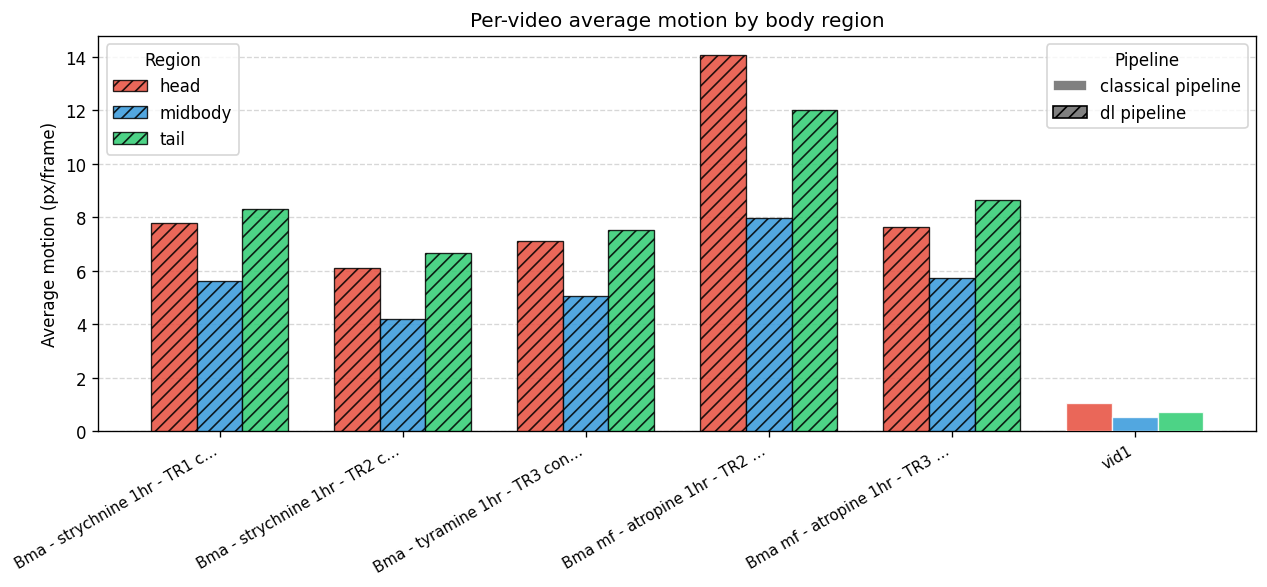

In [9]:
# ── Chart 1: Per-video grouped bar (avg head / midbody / tail) ────────────────
# Bars are coloured by body region.
# When both classical and YOLO jobs exist, a hatch pattern marks the YOLO bars
# and a second legend explains the distinction.

videos    = per_video_df["video"].tolist()
pipelines = per_video_df["pipeline"].tolist()
n         = len(videos)
regions   = ["head", "midbody", "tail"]
width     = 0.25
x         = np.arange(n)

fig, ax = plt.subplots(figsize=(max(8, n * 1.8), 5))

first_bar: dict = {}
for i, region in enumerate(regions):
    bars = ax.bar(
        x + (i - 1) * width,
        per_video_df[f"avg_{region}"],
        width=width,
        color=REGION_COLORS[region],
        alpha=0.85,
        zorder=3,
    )
    first_bar[region] = bars[0]
    for bar, pl in zip(bars, pipelines):
        bar.set_hatch(PIPELINE_HATCHES.get(pl, ""))
        bar.set_edgecolor(PIPELINE_EDGE.get(pl, "white"))
        bar.set_linewidth(0.8)

ax.set_xticks(x)
ax.set_xticklabels([_shorten(v) for v in videos], rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Average motion (px/frame)")
ax.set_title("Per-video average motion by body region")
ax.yaxis.grid(True, linestyle="--", alpha=0.5, zorder=0)
ax.set_axisbelow(True)

region_legend = ax.legend(
    handles=list(first_bar.values()),
    labels=list(first_bar.keys()),
    title="Region", loc="upper left",
)

unique_pipelines = sorted(set(pipelines))
if len(unique_pipelines) > 1:
    pipeline_patches = [
        mpatches.Patch(
            facecolor="grey",
            hatch=PIPELINE_HATCHES.get(pl, ""),
            edgecolor=PIPELINE_EDGE.get(pl, "white"),
            label=f"{pl} pipeline",
        )
        for pl in unique_pipelines
    ]
    ax.add_artist(region_legend)
    ax.legend(handles=pipeline_patches, title="Pipeline", loc="upper right")
else:
    ax.text(
        0.99, 0.98, f"pipeline: {unique_pipelines[0]}",
        transform=ax.transAxes, ha="right", va="top", fontsize=8, color="dimgrey",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7),
    )

plt.tight_layout()
plt.savefig(SAVE_DIR / "chart1_per_video_bar.png", dpi=150, bbox_inches="tight")
plt.show()

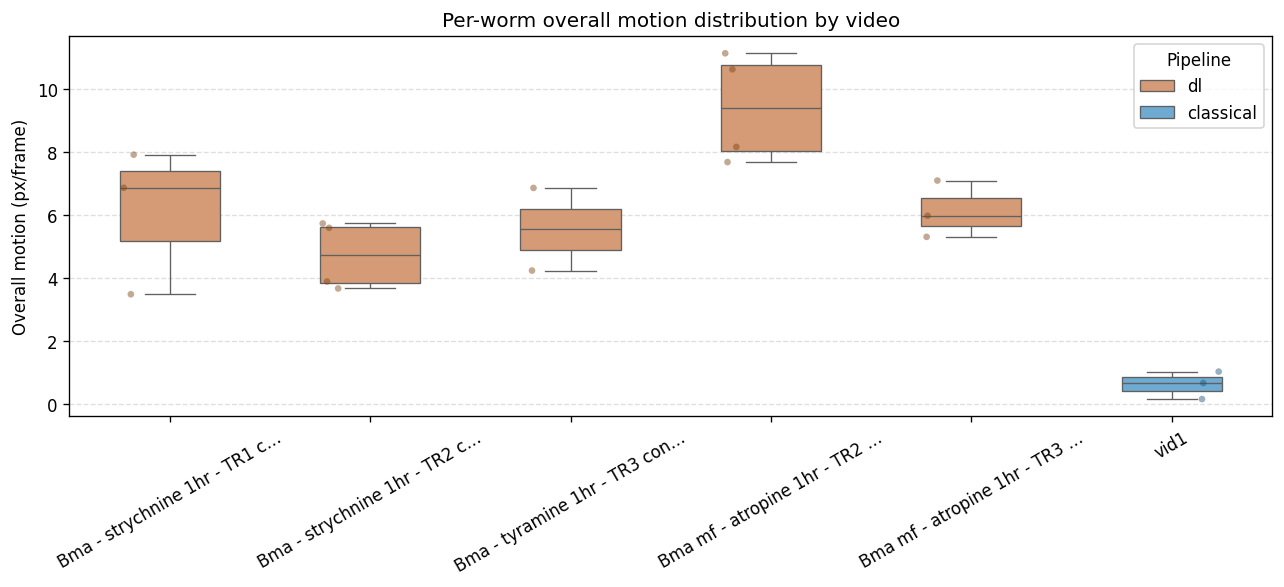

In [10]:
# ── Chart 2: Per-worm overall motion distribution by video (box + strip) ──────
# hue = pipeline so classical and YOLO worms are always colour-coded separately.

pw_plot = per_worm_df.copy()
pw_plot["video_short"] = pw_plot["video"].apply(_shorten)

# Stable ordering: same order as per_video_df
vid_order = [_shorten(v) for v in per_video_df["video"].tolist()]

fig, ax = plt.subplots(figsize=(max(8, n * 1.8), 5))

sns.boxplot(
    data=pw_plot,
    x="video_short", y="overall",
    hue="pipeline",
    order=vid_order,
    palette=PIPELINE_PALETTE,
    width=0.5, linewidth=0.8,
    flierprops={"marker": "o", "markersize": 3, "alpha": 0.5},
    ax=ax,
)
sns.stripplot(
    data=pw_plot,
    x="video_short", y="overall",
    hue="pipeline",
    order=vid_order,
    palette={"classical": "#1a5276", "dl": "#784212"},
    dodge=True, size=4, alpha=0.45, jitter=True,
    ax=ax, legend=False,
)

ax.set_xlabel("")
ax.set_ylabel("Overall motion (px/frame)")
ax.set_title("Per-worm overall motion distribution by video")
ax.tick_params(axis="x", rotation=30)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)

# Deduplicate legend (boxplot may add duplicate handles)
handles, labels = ax.get_legend_handles_labels()
seen_lbl: dict = {}
for h, l in zip(handles, labels):
    if l not in seen_lbl:
        seen_lbl[l] = h
ax.legend(seen_lbl.values(), seen_lbl.keys(), title="Pipeline")

plt.tight_layout()
plt.savefig(SAVE_DIR / "chart2_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

Drill-down video : Bma - strychnine 1hr - TR2 control.mp4
To change it, set DRILL_DOWN_VIDEO = '<exact video name>' and re-run this cell.


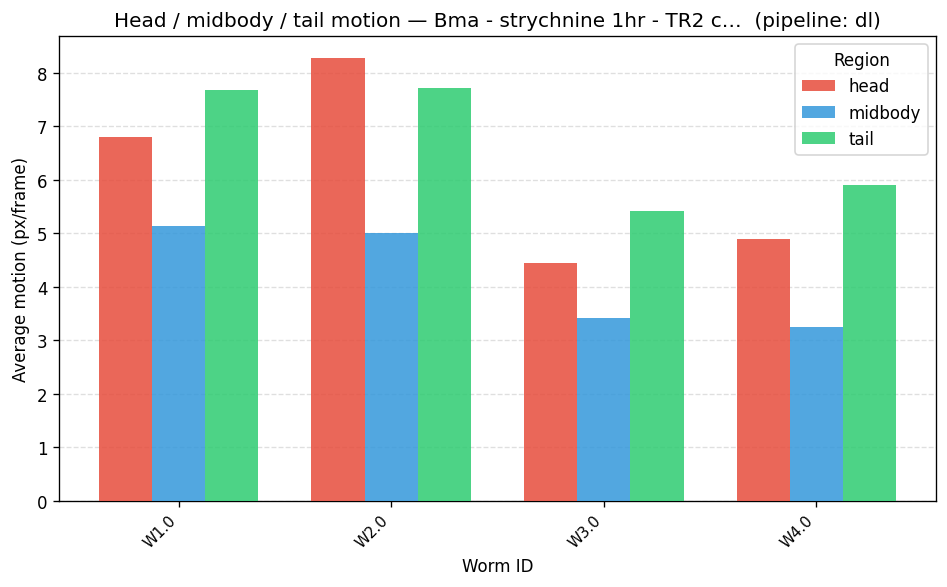

In [11]:
# ── Chart 3: Single-video drill-down (head / midbody / tail per worm) ─────────
# Default: the video with the most worms.  Change DRILL_DOWN_VIDEO to any value
# from combined_per_worm.csv to pivot to a different video.

DRILL_DOWN_VIDEO = per_worm_df.groupby("video")["worm_id"].count().idxmax()

print(f"Drill-down video : {DRILL_DOWN_VIDEO}")
print("To change it, set DRILL_DOWN_VIDEO = '<exact video name>' and re-run this cell.")

dv = per_worm_df[per_worm_df["video"] == DRILL_DOWN_VIDEO].copy()
dv["worm_label"] = "W" + dv["worm_id"].astype(str)

# Sort worm labels numerically where possible
worm_order = sorted(
    dv["worm_label"].unique(),
    key=lambda s: int(s[1:]) if s[1:].isdigit() else s,
)

n_worms = len(worm_order)
regions = ["head", "midbody", "tail"]
width   = 0.25
xi      = np.arange(n_worms)

fig, ax = plt.subplots(figsize=(max(8, n_worms * 1.0), 5))

for i, region in enumerate(regions):
    vals = [
        float(dv.loc[dv["worm_label"] == wl, region].iloc[0])
        for wl in worm_order
    ]
    ax.bar(
        xi + (i - 1) * width,
        vals,
        width=width,
        color=REGION_COLORS[region],
        alpha=0.85,
        label=region,
        zorder=3,
    )

ax.set_xticks(xi)
ax.set_xticklabels(worm_order, rotation=45, ha="right", fontsize=9)
ax.set_xlabel("Worm ID")
ax.set_ylabel("Average motion (px/frame)")
pl_label   = dv["pipeline"].iloc[0]
short_name = _shorten(DRILL_DOWN_VIDEO)
ax.set_title(f"Head / midbody / tail motion — {short_name}  (pipeline: {pl_label})")
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
ax.legend(title="Region")

plt.tight_layout()
plt.savefig(SAVE_DIR / "chart3_drill_down.png", dpi=150, bbox_inches="tight")
plt.show()